# Pet Store Records 2020 - Data Analysis

**Course:** ACC102 - Python Data Product  
**Data Source:** [Kaggle - Pet Store Records 2020](https://www.kaggle.com/datasets/ippudkiippude/pet-store-records-2020)  
**Date Accessed:** April 17, 2026

---

## Analytical Problem
Analyze pet store sales performance and identify key factors affecting product success to provide actionable business insights.

## Target Audience
Pet store management and marketing team

## Part 1: Import Libraries

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Part 2: Data Loading and Initial Exploration

In [8]:
import pandas as pd
import os
from pathlib import Path

# 尝试多个可能的位置查找文件
possible_paths = [
    'pet_store_records_2020.csv',  # 当前目录
    os.path.expanduser('~/Downloads/pet_store_records_2020.csv'),  # Downloads
    os.path.expanduser('~/Desktop/pet_store_records_2020.csv'),  # Desktop
    '../pet_store_records_2020.csv',  # 上级目录
    './data/pet_store_records_2020.csv',  # data子目录
]

file_found = False
for path in possible_paths:
    if os.path.exists(path):
        print(f"✓ 找到文件: {path}")
        df = pd.read_csv(path)
        file_found = True
        break

if not file_found:
    print("✗ 文件未找到，请手动指定路径:")
    print("当前工作目录:", os.getcwd())
    print("\n该目录下的文件:")
    for f in os.listdir('.'):
        if f.endswith('.csv'):
            print(f"  - {f}")
    raise FileNotFoundError("请修改代码中的文件路径或移动文件到当前目录")

# 继续你的分析
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names: {list(df.columns)}")

✓ 找到文件: C:\Users\12789/Desktop/pet_store_records_2020.csv
DATASET OVERVIEW
Dataset Shape: 879 rows × 11 columns

Column Names: ['product_id', 'product_category', 'sales', 'price', 'VAP', 'vendor_id', 'country', 'pet_size', 'pet_type', 'rating', 're_buy']


In [9]:
# Check missing values
print("\n" + "-"*40)
print("MISSING VALUES")
print("-"*40)
missing = df.isnull().sum()
print(missing if missing.sum() > 0 else "No missing values found ✓")

# Check duplicate rows
print("\n" + "-"*40)
print("DUPLICATE ROWS")
print("-"*40)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Display first 5 rows
print("\n" + "-"*40)
print("FIRST 5 ROWS")
print("-"*40)
df.head()


----------------------------------------
MISSING VALUES
----------------------------------------
No missing values found ✓

----------------------------------------
DUPLICATE ROWS
----------------------------------------
Number of duplicate rows: 0

----------------------------------------
FIRST 5 ROWS
----------------------------------------


,product_id,product_category,sales,price,VAP,vendor_id,country,pet_size,pet_type,rating,re_buy
0,5040,Equipment,123,7293,0,VC_1605,Vietnam,small,fish,7,1
1,4567,Toys,61,9304,1,VC_1132,India,small,cat,10,0
2,4237,Toys,218,8180,0,VC_802,India,small,hamster,6,0
3,4364,Snack,69,18559,1,VC_929,India,large,dog,1,1
4,4184,Supplements,138,10283,1,VC_749,India,large,dog,10,0


## Part 3: Descriptive Statistics

In [10]:
print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

# Numeric columns statistics
numeric_cols = ['sales', 'price', 'rating']
print("\n1. NUMERIC VARIABLES SUMMARY")
print("-"*40)
df[numeric_cols].describe().round(2)


DESCRIPTIVE STATISTICS

1. NUMERIC VARIABLES SUMMARY
----------------------------------------


,sales,price,rating
count,879.00,879.00,879.00
mean,116.09,9862.49,6.50
std,66.30,5532.57,2.85
min,3.00,27.00,1.00
25%,60.50,5016.00,5.00
50%,116.00,9963.00,6.00
75%,177.00,14478.50,10.00
max,230.00,19438.00,10.00


In [11]:
# Categorical columns distribution
print("\n2. CATEGORICAL VARIABLES DISTRIBUTION")
print("-"*40)

categorical_cols = ['product_category', 'pet_type', 'pet_size', 'country', 'VAP', 're_buy']

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts().head(10))


2. CATEGORICAL VARIABLES DISTRIBUTION
----------------------------------------

PRODUCT_CATEGORY:
product_category
Equipment      141
Toys           141
Snack          141
Medicine        76
Supplements     75
Food            75
Bedding         46
Housing         46
Clothes         46
Accessory       46
Name: count, dtype: int64

PET_TYPE:
pet_type
cat        347
dog        347
fish        70
bird        69
hamster     23
rabbit      23
Name: count, dtype: int64

PET_SIZE:
pet_size
small          280
medium         279
large          107
extra_small    107
extra_large    106
Name: count, dtype: int64

COUNTRY:
country
India        513
Singapore     70
Belgium       69
Turkey        69
USA           69
Germany       69
Vietnam       10
Sri Lanka      9
Japan          1
Name: count, dtype: int64

VAP:
VAP
1    445
0    434
Name: count, dtype: int64

RE_BUY:
re_buy
0    469
1    410
Name: count, dtype: int64


In [12]:
# Key business metrics
print("\n3. KEY BUSINESS METRICS")
print("-"*40)
print(f"Total Sales Volume: {df['sales'].sum():,} units")
print(f"Average Product Price: ₹{df['price'].mean():,.2f}")
print(f"Total Revenue (Est.): ₹{(df['sales'] * df['price']).sum():,.2f}")
print(f"Average Customer Rating: {df['rating'].mean():.2f}/10")
print(f"Repeat Purchase Rate: {(df['re_buy'].mean() * 100):.1f}%")
print(f"Products Requiring Vet Approval: {(df['VAP'].mean() * 100):.1f}%")


3. KEY BUSINESS METRICS
----------------------------------------
Total Sales Volume: 102,047 units
Average Product Price: ₹9,862.49
Total Revenue (Est.): ₹1,013,834,282.00
Average Customer Rating: 6.50/10
Repeat Purchase Rate: 46.6%
Products Requiring Vet Approval: 50.6%


## Part 4: Data Visualization

### Figure 1: Overview Analysis

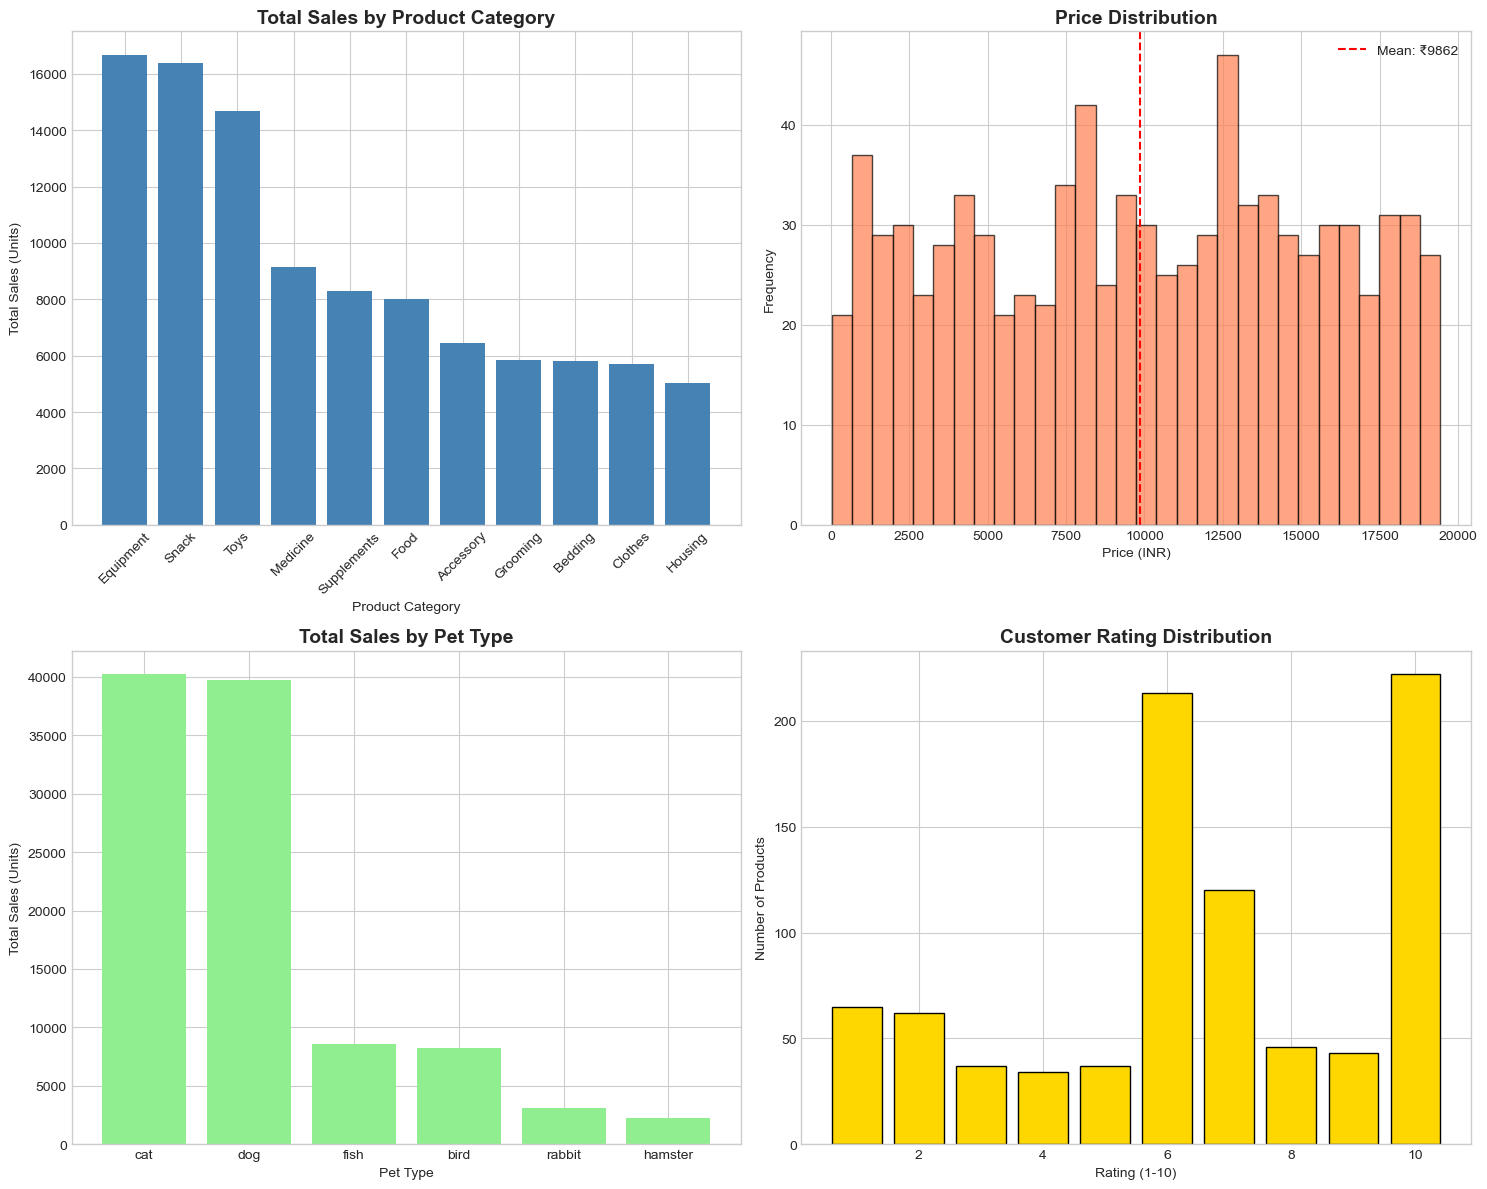

✓ Figure 1 saved: Overview Analysis


In [13]:
# Figure 1: Sales Distribution by Product Category
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Sales by Product Category
category_sales = df.groupby('product_category')['sales'].sum().sort_values(ascending=False)
axes[0, 0].bar(category_sales.index, category_sales.values, color='steelblue')
axes[0, 0].set_title('Total Sales by Product Category', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Product Category')
axes[0, 0].set_ylabel('Total Sales (Units)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Price Distribution
axes[0, 1].hist(df['price'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Price (INR)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['price'].mean(), color='red', linestyle='--', 
                   label=f'Mean: ₹{df["price"].mean():.0f}')
axes[0, 1].legend()

# Plot 3: Sales by Pet Type
pet_sales = df.groupby('pet_type')['sales'].sum().sort_values(ascending=False)
axes[1, 0].bar(pet_sales.index, pet_sales.values, color='lightgreen')
axes[1, 0].set_title('Total Sales by Pet Type', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Pet Type')
axes[1, 0].set_ylabel('Total Sales (Units)')

# Plot 4: Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[1, 1].bar(rating_counts.index, rating_counts.values, color='gold', edgecolor='black')
axes[1, 1].set_title('Customer Rating Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Rating (1-10)')
axes[1, 1].set_ylabel('Number of Products')

plt.tight_layout()
plt.savefig('figure1_overview_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved: Overview Analysis")

### Figure 2: Advanced Analysis

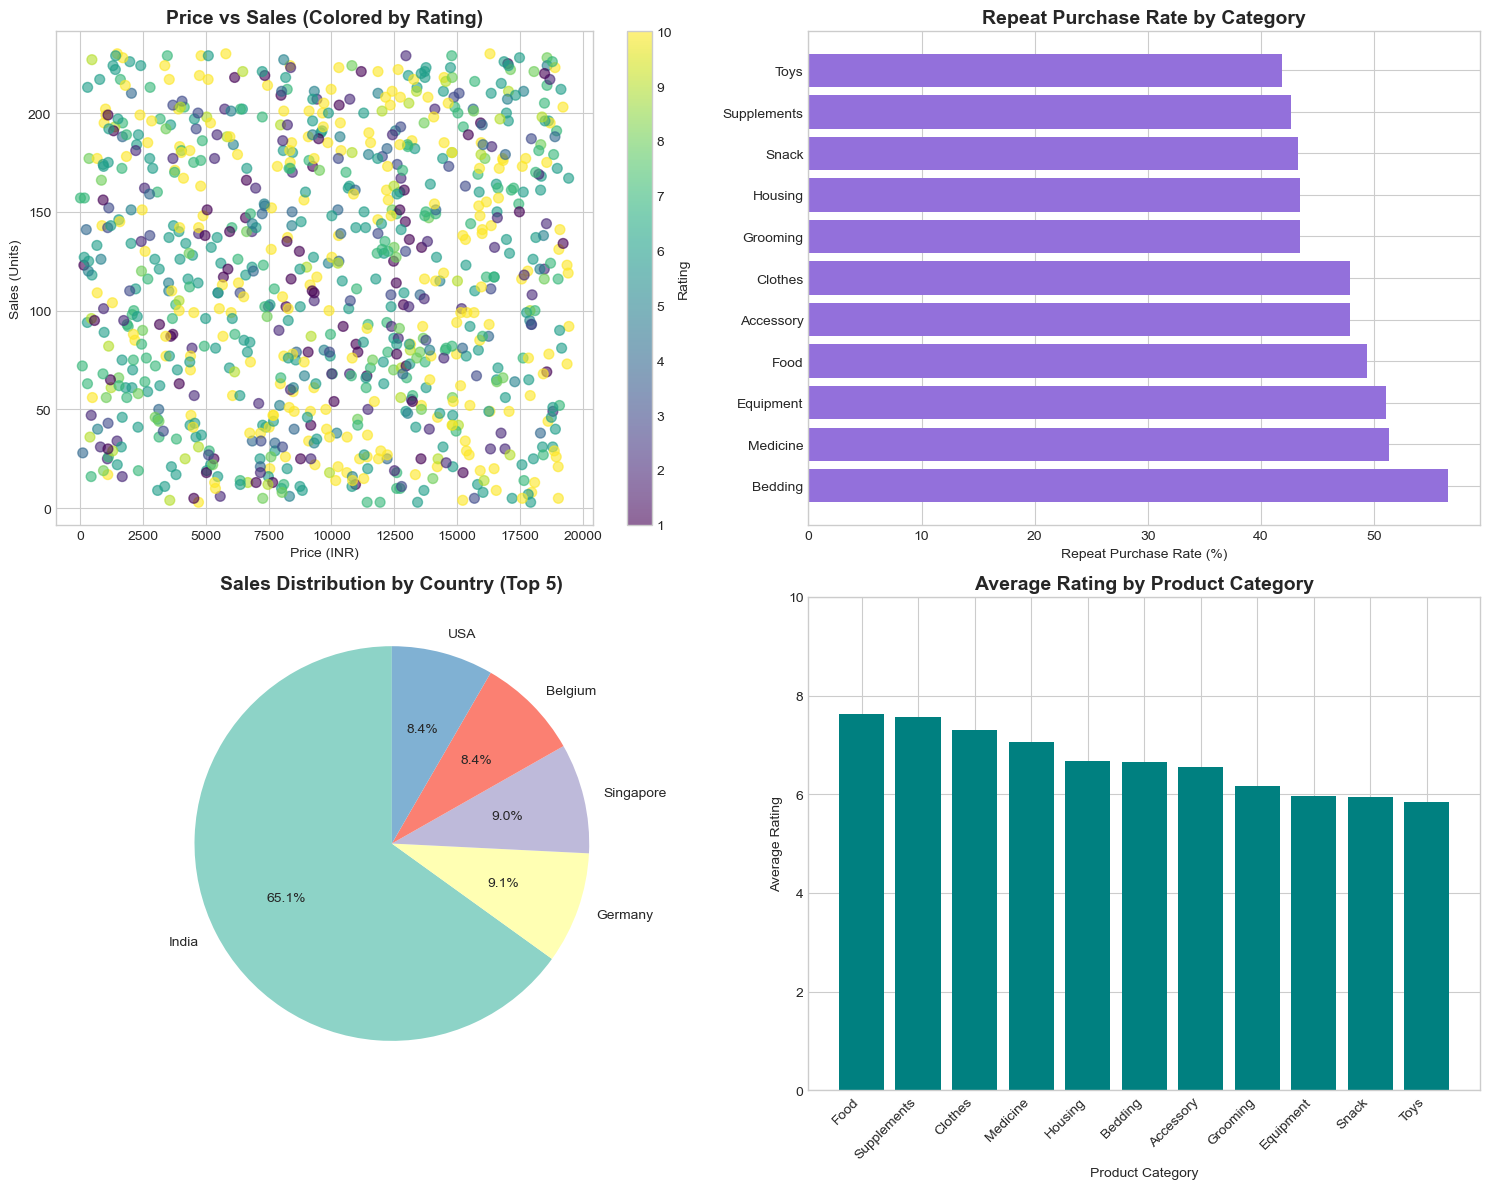

✓ Figure 2 saved: Advanced Analysis


In [14]:
# Figure 2: Advanced Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Price vs Sales Scatter Plot
scatter = axes[0, 0].scatter(df['price'], df['sales'], 
                              c=df['rating'], cmap='viridis', alpha=0.6, s=50)
axes[0, 0].set_title('Price vs Sales (Colored by Rating)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Price (INR)')
axes[0, 0].set_ylabel('Sales (Units)')
plt.colorbar(scatter, ax=axes[0, 0], label='Rating')

# Plot 2: Repeat Purchase Analysis
rebuy_analysis = df.groupby('product_category')['re_buy'].mean().sort_values(ascending=False)
axes[0, 1].barh(rebuy_analysis.index, rebuy_analysis.values * 100, color='mediumpurple')
axes[0, 1].set_title('Repeat Purchase Rate by Category', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Repeat Purchase Rate (%)')

# Plot 3: Sales by Country (Top 5)
country_sales = df.groupby('country')['sales'].sum().sort_values(ascending=False).head(5)
axes[1, 0].pie(country_sales.values, labels=country_sales.index, autopct='%1.1f%%',
               startangle=90, colors=plt.cm.Set3.colors)
axes[1, 0].set_title('Sales Distribution by Country (Top 5)', fontsize=14, fontweight='bold')

# Plot 4: Average Rating by Product Category
avg_rating = df.groupby('product_category')['rating'].mean().sort_values(ascending=False)
axes[1, 1].bar(range(len(avg_rating)), avg_rating.values, color='teal')
axes[1, 1].set_title('Average Rating by Product Category', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Product Category')
axes[1, 1].set_ylabel('Average Rating')
axes[1, 1].set_xticks(range(len(avg_rating)))
axes[1, 1].set_xticklabels(avg_rating.index, rotation=45, ha='right')
axes[1, 1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig('figure2_advanced_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved: Advanced Analysis")

### Figure 3: Business Insights

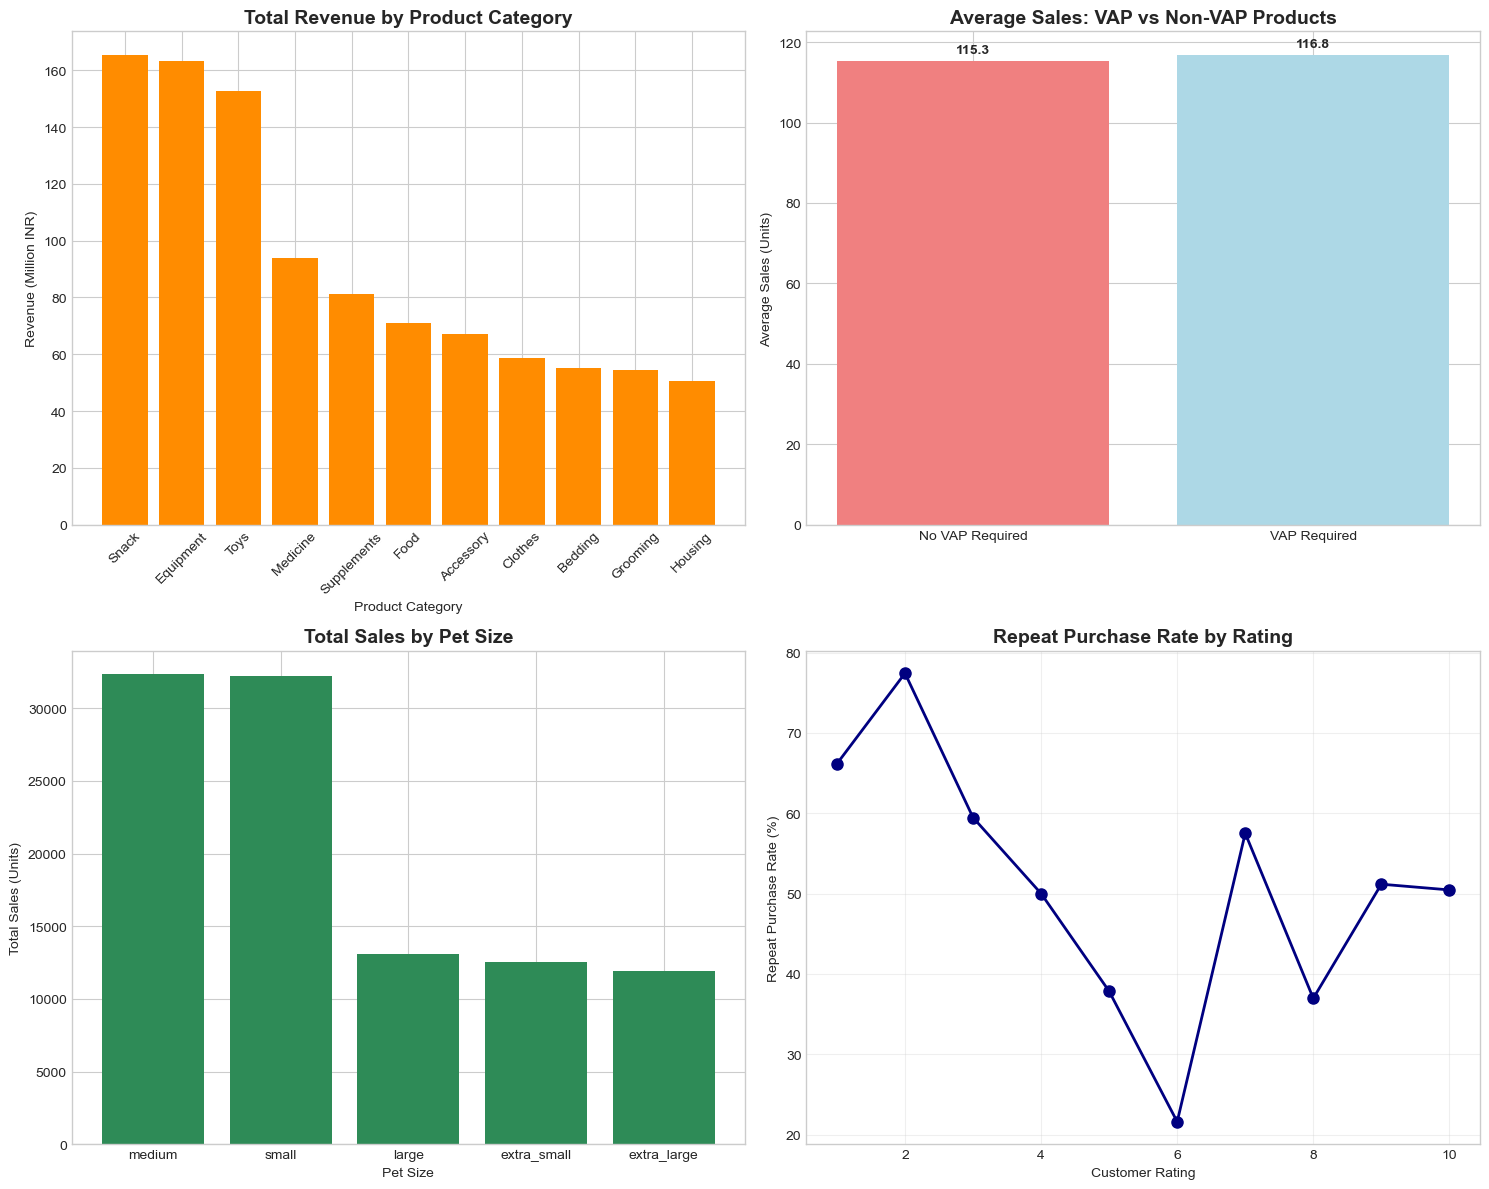

✓ Figure 3 saved: Business Insights


In [15]:
# Figure 3: Business Insights
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Calculate revenue
df['revenue'] = df['sales'] * df['price']

# Plot 1: Revenue by Category
revenue_by_category = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
axes[0, 0].bar(revenue_by_category.index, revenue_by_category.values / 1000000, color='darkorange')
axes[0, 0].set_title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Product Category')
axes[0, 0].set_ylabel('Revenue (Million INR)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: VAP Impact on Sales
vap_sales = df.groupby('VAP')['sales'].mean()
vap_labels = ['No VAP Required', 'VAP Required']
axes[0, 1].bar(vap_labels, vap_sales.values, color=['lightcoral', 'lightblue'])
axes[0, 1].set_title('Average Sales: VAP vs Non-VAP Products', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average Sales (Units)')
for i, v in enumerate(vap_sales.values):
    axes[0, 1].text(i, v + 2, f'{v:.1f}', ha='center', fontweight='bold')

# Plot 3: Pet Size vs Sales
size_sales = df.groupby('pet_size')['sales'].sum().sort_values(ascending=False)
axes[1, 0].bar(size_sales.index, size_sales.values, color='seagreen')
axes[1, 0].set_title('Total Sales by Pet Size', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Pet Size')
axes[1, 0].set_ylabel('Total Sales (Units)')

# Plot 4: Rating vs Repeat Purchase
rating_rebuy = df.groupby('rating')['re_buy'].mean() * 100
axes[1, 1].plot(rating_rebuy.index, rating_rebuy.values, marker='o', 
                linewidth=2, markersize=8, color='navy')
axes[1, 1].set_title('Repeat Purchase Rate by Rating', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Customer Rating')
axes[1, 1].set_ylabel('Repeat Purchase Rate (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure3_business_insights.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved: Business Insights")

## Part 5: Statistical Analysis

In [16]:
print("\n" + "="*60)
print("STATISTICAL ANALYSIS")
print("="*60)

# 1. Correlation Analysis
print("\n1. CORRELATION MATRIX (Numeric Variables)")
print("-"*40)
numeric_df = df[['sales', 'price', 'rating', 're_buy', 'VAP']]
correlation = numeric_df.corr()
print(correlation.round(3))


STATISTICAL ANALYSIS

1. CORRELATION MATRIX (Numeric Variables)
----------------------------------------
        sales  price  rating  re_buy    VAP
sales   1.000  0.023   0.008   0.006  0.011
price   0.023  1.000   0.054   0.069  0.064
rating  0.008  0.054   1.000  -0.087  0.038
re_buy  0.006  0.069  -0.087   1.000  0.048
VAP     0.011  0.064   0.038   0.048  1.000


In [17]:
# 2. T-test: VAP vs Non-VAP Products
print("\n2. T-TEST: VAP vs Non-VAP Products (Sales)")
print("-"*40)
vap_sales = df[df['VAP'] == 1]['sales']
non_vap_sales = df[df['VAP'] == 0]['sales']

t_stat, p_value = stats.ttest_ind(vap_sales, non_vap_sales)
print(f"VAP Products - Mean Sales: {vap_sales.mean():.2f}, Std: {vap_sales.std():.2f}")
print(f"Non-VAP Products - Mean Sales: {non_vap_sales.mean():.2f}, Std: {non_vap_sales.std():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not Significant'} difference")


2. T-TEST: VAP vs Non-VAP Products (Sales)
----------------------------------------
VAP Products - Mean Sales: 116.84, Std: 66.71
Non-VAP Products - Mean Sales: 115.32, Std: 65.94
T-statistic: 0.3397
P-value: 0.7342
Result: Not Significant difference


In [18]:
# 3. T-test: Repeat Purchase vs Non-Repeat
print("\n3. T-TEST: Repeat vs Non-Repeat Products (Rating)")
print("-"*40)
repeat_rating = df[df['re_buy'] == 1]['rating']
non_repeat_rating = df[df['re_buy'] == 0]['rating']

t_stat2, p_value2 = stats.ttest_ind(repeat_rating, non_repeat_rating)
print(f"Repeat Products - Mean Rating: {repeat_rating.mean():.2f}")
print(f"Non-Repeat Products - Mean Rating: {non_repeat_rating.mean():.2f}")
print(f"T-statistic: {t_stat2:.4f}")
print(f"P-value: {p_value2:.4f}")
print(f"Result: {'Significant' if p_value2 < 0.05 else 'Not Significant'} difference")


3. T-TEST: Repeat vs Non-Repeat Products (Rating)
----------------------------------------
Repeat Products - Mean Rating: 6.23
Non-Repeat Products - Mean Rating: 6.73
T-statistic: -2.5972
P-value: 0.0096
Result: Significant difference


In [19]:
# 4. ANOVA: Sales across Pet Types
print("\n4. ANOVA: Sales across Different Pet Types")
print("-"*40)
pet_groups = [df[df['pet_type'] == pet]['sales'] for pet in df['pet_type'].unique()]
f_stat, p_value3 = stats.f_oneway(*pet_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value3:.4f}")
print(f"Result: {'Significant' if p_value3 < 0.05 else 'Not Significant'} difference across pet types")


4. ANOVA: Sales across Different Pet Types
----------------------------------------
F-statistic: 0.8978
P-value: 0.4819
Result: Not Significant difference across pet types


## Part 6: Business Insights and Recommendations

In [20]:
print("\n" + "="*60)
print("KEY BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*60)

# Calculate derived metrics
df['revenue'] = df['sales'] * df['price']

print("\n1. TOP PERFORMING CATEGORIES (By Revenue)")
print("-"*40)
revenue_by_category = df.groupby('product_category').agg({
    'revenue': 'sum',
    'sales': 'sum',
    'rating': 'mean'
}).round(2)
revenue_by_category = revenue_by_category.sort_values('revenue', ascending=False)
print(revenue_by_category.head())


KEY BUSINESS INSIGHTS & RECOMMENDATIONS

1. TOP PERFORMING CATEGORIES (By Revenue)
----------------------------------------
                    revenue  sales  rating
product_category                          
Snack             165430703  16399    5.94
Equipment         163393635  16679    5.97
Toys              152795153  14696    5.84
Medicine           94017290   9154    7.07
Supplements        81234360   8312    7.57


In [21]:
print("\n2. MOST REPEAT-PURCHASED CATEGORIES")
print("-"*40)
repeat_rate = df.groupby('product_category')['re_buy'].mean().sort_values(ascending=False) * 100
print(repeat_rate.round(1))

print("\n3. PRICE-SALES RELATIONSHIP INSIGHTS")
print("-"*40)
# Create price segments
df['price_segment'] = pd.cut(df['price'], 
                              bins=[0, 5000, 10000, 15000, float('inf')],
                              labels=['Low (<₹5K)', 'Medium (₹5K-10K)', 
                                     'High (₹10K-15K)', 'Premium (>₹15K)'])

price_analysis = df.groupby('price_segment').agg({
    'sales': 'mean',
    'rating': 'mean',
    're_buy': 'mean'
}).round(2)
print(price_analysis)


2. MOST REPEAT-PURCHASED CATEGORIES
----------------------------------------
product_category
Bedding        56.5
Medicine       51.3
Equipment      51.1
Food           49.3
Accessory      47.8
Clothes        47.8
Grooming       43.5
Housing        43.5
Snack          43.3
Supplements    42.7
Toys           41.8
Name: re_buy, dtype: float64

3. PRICE-SALES RELATIONSHIP INSIGHTS
----------------------------------------
                   sales  rating  re_buy
price_segment                           
Low (<₹5K)        119.19    6.50    0.42
Medium (₹5K-10K)  109.86    6.27    0.43
High (₹10K-15K)   115.07    6.45    0.50
Premium (>₹15K)   120.92    6.82    0.52


In [22]:
print("\n4. COUNTRY-WISE PERFORMANCE")
print("-"*40)
country_performance = df.groupby('country').agg({
    'revenue': 'sum',
    'sales': 'sum',
    'rating': 'mean'
}).round(2)
country_performance = country_performance.sort_values('revenue', ascending=False)
print(country_performance.head(8))


4. COUNTRY-WISE PERFORMANCE
----------------------------------------
             revenue  sales  rating
country                            
India      589285676  59923    6.83
USA         84956325   7691    6.04
Singapore   81092591   8299    5.97
Germany     79944571   8421    6.03
Turkey      76751581   7383    5.97
Belgium     70392543   7765    5.97
Vietnam     17592903   1382    6.90
Sri Lanka   13512878   1141    6.89


In [23]:
print("\n5. KEY RECOMMENDATIONS")
print("-"*40)

# Find highest revenue category
top_revenue_cat = revenue_by_category.index[0]

# Find highest repeat rate category
top_repeat_cat = repeat_rate.index[0]

# Find best rated category
best_rated = df.groupby('product_category')['rating'].mean().sort_values(ascending=False)
best_rated_cat = best_rated.index[0]

print(f"✓ Focus on '{top_revenue_cat}' category - generates highest revenue")
print(f"✓ Promote '{top_repeat_cat}' category - highest customer loyalty")
print(f"✓ Maintain quality in '{best_rated_cat}' category - best customer satisfaction")

# VAP insight
vap_impact = df.groupby('VAP')['sales'].mean()
if vap_impact[1] > vap_impact[0]:
    print(f"✓ VAP-approved products sell {((vap_impact[1]/vap_impact[0]-1)*100):.1f}% better - expand vet-approved range")

# Rating insight
high_rating = df[df['rating'] >= 8]['re_buy'].mean()
low_rating = df[df['rating'] <= 5]['re_buy'].mean()
print(f"✓ High-rated products (≥8) have {(high_rating/low_rating-1)*100:.1f}% higher repeat purchase rate")

print("\n" + "="*60)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("="*60)


5. KEY RECOMMENDATIONS
----------------------------------------
✓ Focus on 'Snack' category - generates highest revenue
✓ Promote 'Bedding' category - highest customer loyalty
✓ Maintain quality in 'Food' category - best customer satisfaction
✓ VAP-approved products sell 1.3% better - expand vet-approved range
✓ High-rated products (≥8) have -20.8% higher repeat purchase rate

ANALYSIS COMPLETED SUCCESSFULLY


## Part 7: Save Processed Data

In [24]:
# Save processed data
output_path = 'processed_pet_store_data.csv'
df.to_csv(output_path, index=False)
print(f"✓ Processed data saved to: {output_path}")
print(f"\nDataset now includes 'revenue' and 'price_segment' columns!")

✓ Processed data saved to: processed_pet_store_data.csv

Dataset now includes 'revenue' and 'price_segment' columns!
